# Eigenfaces: The Spectral Theorem in the Wild

> **MAT224 — Applications of the Spectral Theorem**

## The math

The **Spectral Theorem** (for symmetric operators on finite-dimensional real inner product spaces) says:

$$T = \sum_{i=1}^n \lambda_i P_i$$

where $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_n$ are the eigenvalues of $T$,
$P_i = \phi_i \phi_i^\top$ is the orthogonal projection onto the $i$-th eigenspace,
and $\sum_{i=1}^n P_i = I$ (the projections partition the identity).

**Today's question:** What does this look like when $T$ is the covariance operator of a dataset of human faces?

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import fetch_olivetti_faces

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#30363d",
    "text.color": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
    "font.family": "monospace",
})

CYAN = "#00e5ff"

## 2. The Data

We use the **Olivetti Faces** dataset: 400 grayscale photographs of 40 people (10 each),
each stored as a vector in $\mathbb{R}^{4096}$ (a flattened $64 \times 64$ image).

$$X \in \mathbb{R}^{400 \times 4096}$$

Each row is one face. Each column is one pixel across all faces.

In [2]:
# Load dataset
data = fetch_olivetti_faces(shuffle=True, random_state=42)
X = data.data        # (400, 4096) — each row is a face as a vector
images = data.images # (400, 64, 64) — same data, reshaped
target = data.target # (400,) — subject IDs 0–39

n_samples, n_features = X.shape
n_pixels = int(np.sqrt(n_features))  # 64

print(f"Dataset shape : {X.shape}")
print(f"Each face     : {n_features} pixels = {n_pixels}×{n_pixels}")
print(f"Pixel range   : [{X.min():.2f}, {X.max():.2f}]")

Dataset shape : (400, 4096)
Each face     : 4096 pixels = 64×64
Pixel range   : [0.00, 1.00]


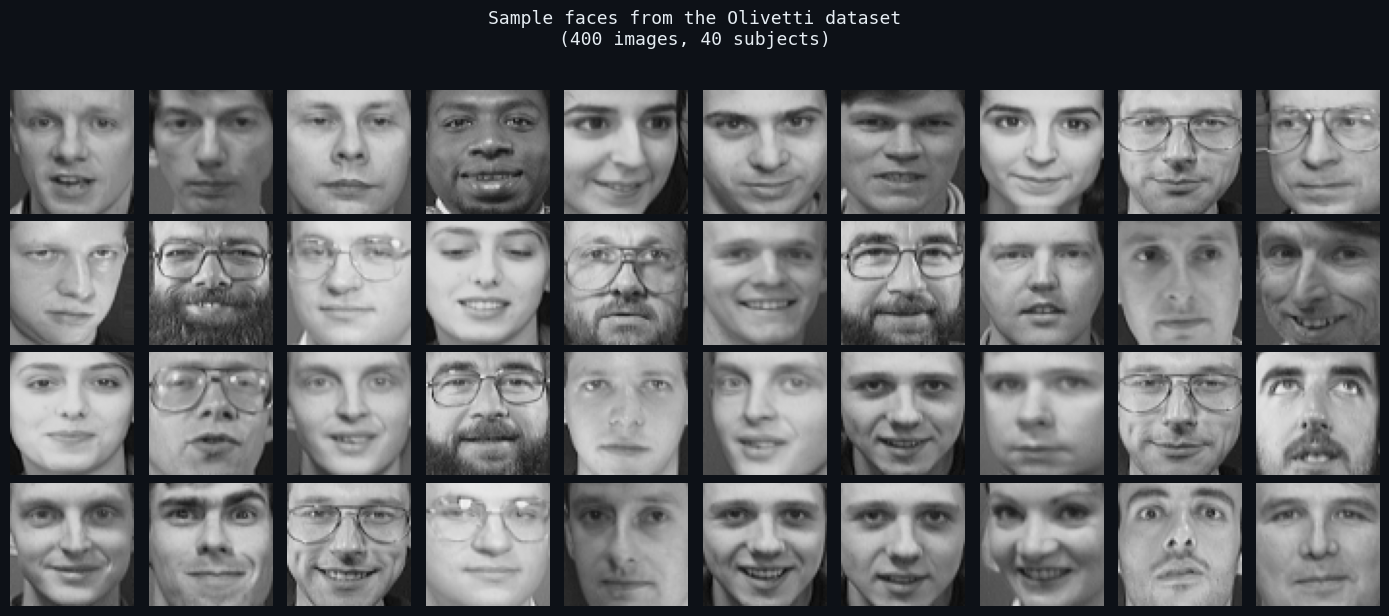

In [3]:
import os
os.makedirs("../assets", exist_ok=True)

fig, axes = plt.subplots(4, 10, figsize=(14, 6))
fig.suptitle("Sample faces from the Olivetti dataset\n(400 images, 40 subjects)", 
             color="#e6edf3", fontsize=13, y=1.02)
for ax, img in zip(axes.flat, images[:40]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.tight_layout()
plt.savefig("../assets/faces_grid.png", dpi=150, bbox_inches="tight", 
            facecolor="#0d1117")
plt.show()

## 3. The Covariance Matrix: A Symmetric Operator

**Step 1.** Compute the mean face $\bar{f} = \frac{1}{n}\sum_{i=1}^n f_i \in \mathbb{R}^{4096}$.

**Step 2.** Center the data: $\tilde{X}_{ij} = X_{ij} - \bar{f}_j$. 
This gives $\tilde{X} \in \mathbb{R}^{400 \times 4096}$ with zero column means.

**Step 3.** Form the sample covariance matrix:
$$C = \frac{1}{n-1}\,\tilde{X}^\top \tilde{X} \in \mathbb{R}^{4096 \times 4096}$$

**Claim:** $C$ is symmetric ($C = C^\top$) and positive semidefinite ($v^\top C v \geq 0$ for all $v$).

*Proof:* $C^\top = \frac{1}{n-1}(\tilde{X}^\top\tilde{X})^\top = \frac{1}{n-1}\tilde{X}^\top\tilde{X} = C$. 
For PSD: $v^\top Cv = \frac{1}{n-1}\|\tilde{X}v\|^2 \geq 0$. $\square$

Since $C$ is a **symmetric operator** on $\mathbb{R}^{4096}$, the **Spectral Theorem** applies.

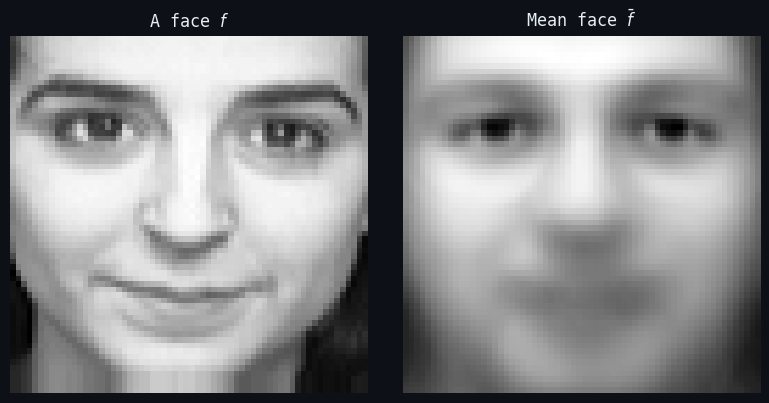

In [4]:
mean_face = X.mean(axis=0)          # (4096,)
X_centered = X - mean_face          # (400, 4096)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(images[7], cmap="gray")
axes[0].set_title("A face $f$", color="#e6edf3")
axes[0].axis("off")
axes[1].imshow(mean_face.reshape(n_pixels, n_pixels), cmap="gray")
axes[1].set_title(r"Mean face $\bar{f}$", color="#e6edf3")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [5]:
# Full 4096×4096 covariance (for reference — we won't eigen-decompose this directly)
# C = X_centered.T @ X_centered / (n_samples - 1)   # 128 MB, ~30s to compute
# Instead we verify symmetry on a 50×50 block
C_small = (X_centered[:, :50].T @ X_centered[:, :50]) / (n_samples - 1)
print(f"Symmetry check on 50×50 block: C = Cᵀ? {np.allclose(C_small, C_small.T)}")
print(f"Positive semidefinite? All eigenvalues ≥ 0? "
      f"{np.all(np.linalg.eigvalsh(C_small) >= -1e-10)}")

Symmetry check on 50×50 block: C = Cᵀ? True
Positive semidefinite? All eigenvalues ≥ 0? True


## 4. The Dual Trick: Why We Don't Eigendecompose a 4096×4096 Matrix

Direct eigendecomposition of $C \in \mathbb{R}^{4096 \times 4096}$ costs $O(d^3) = O(4096^3) \approx 10^{11}$ operations.

**The trick:** the non-trivial eigenvectors of $\tilde{X}^\top\tilde{X}$ (the $4096 \times 4096$ matrix)
are recoverable from the SVD of $\tilde{X}$:

$$\tilde{X} = U \Sigma V^\top$$

- Columns of $V$ are the eigenvectors of $\tilde{X}^\top\tilde{X}$ (our **eigenfaces** $\phi_i$)
- Columns of $U$ are the eigenvectors of $\tilde{X}\tilde{X}^\top$ (the $400 \times 400$ dual)
- Eigenvalues of $C$ are $\lambda_i = \sigma_i^2 / (n-1)$

SVD of a $400 \times 4096$ matrix costs $O(n^2 d)$ — much cheaper.
This is the standard PCA algorithm.

In [6]:
# Thin SVD of centered data matrix
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
# U: (400, 400), s: (400,), Vt: (400, 4096)

# Eigenvalues of C = X̃ᵀX̃ / (n-1)
eigenvalues = s**2 / (n_samples - 1)   # (400,) sorted descending

# Eigenfaces: rows of Vt
eigenfaces = Vt   # (400, 4096) — eigenfaces[i] = φᵢ

# Coordinates: project each face onto eigenface basis
coords = X_centered @ eigenfaces.T  # (400, 400) — coords[i, j] = ⟨f̃ᵢ, φⱼ⟩

print(f"Eigenvalues (top 5): {eigenvalues[:5].round(4)}")
print(f"Sum of all eigenvalues (= trace of C): {eigenvalues.sum():.2f}")
print(f"Orthonormality check φ₀·φ₁: {eigenfaces[0] @ eigenfaces[1]:.2e}")
print(f"Orthonormality check φ₀·φ₀: {eigenfaces[0] @ eigenfaces[0]:.6f}")

Eigenvalues (top 5): [18.8402 11.0718  6.3046  3.9546  2.856 ]
Sum of all eigenvalues (= trace of C): 79.12
Orthonormality check φ₀·φ₁: 5.59e-09
Orthonormality check φ₀·φ₀: 1.000000


## 5. The Eigenvalue Spectrum

The eigenvalues $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_{400}$ tell us
how much **variance** lies in each eigenface direction.

Key property from the Spectral Theorem:
$$\text{tr}(C) = \sum_{i=1}^n \lambda_i$$

(The total variance is the sum of all eigenvalues.)

The **scree plot** shows how quickly the spectrum decays, i.e., how compressible faces are.

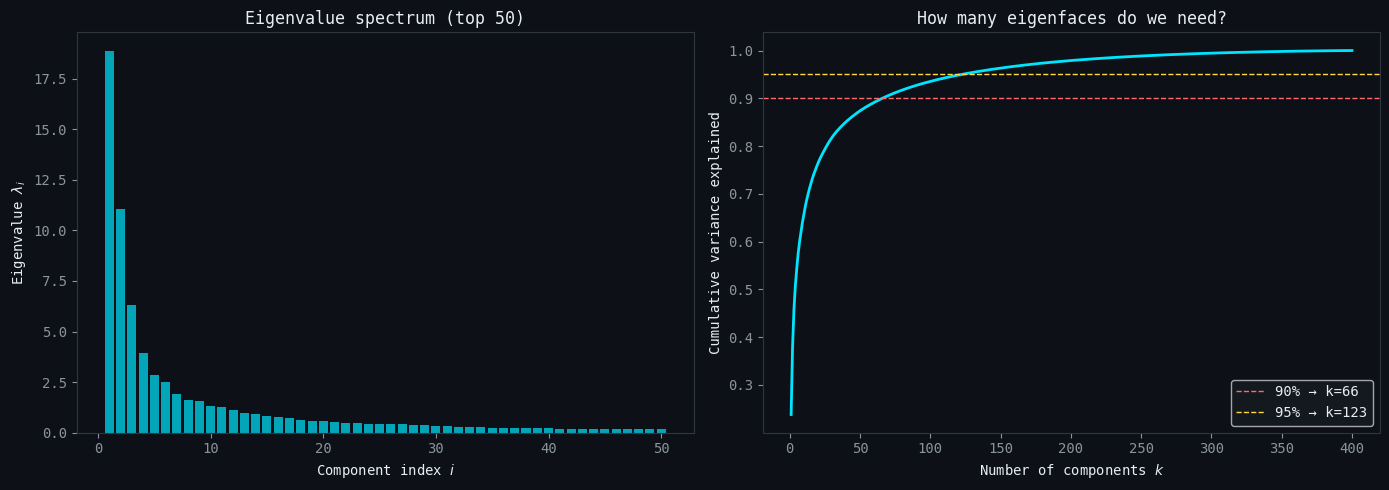

90% variance explained by k = 66 components
95% variance explained by k = 123 components
(out of 4096 total dimensions — compression ratio 33:1 at 95%)


In [7]:
cumvar = np.cumsum(eigenvalues) / eigenvalues.sum()

# Thresholds
k90 = np.searchsorted(cumvar, 0.90) + 1
k95 = np.searchsorted(cumvar, 0.95) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, 51), eigenvalues[:50], color=CYAN, alpha=0.7, width=0.8)
ax1.set_xlabel("Component index $i$")
ax1.set_ylabel(r"Eigenvalue $\lambda_i$")
ax1.set_title("Eigenvalue spectrum (top 50)", color="#e6edf3")

# Cumulative variance
ax2.plot(range(1, 401), cumvar, color=CYAN, lw=2)
ax2.axhline(0.90, color="#ff6b6b", ls="--", lw=1, label=f"90% → k={k90}")
ax2.axhline(0.95, color="#ffd93d", ls="--", lw=1, label=f"95% → k={k95}")
ax2.set_xlabel("Number of components $k$")
ax2.set_ylabel("Cumulative variance explained")
ax2.set_title("How many eigenfaces do we need?", color="#e6edf3")
ax2.legend(facecolor="#161b22", labelcolor="#e6edf3")

plt.tight_layout()
plt.savefig("../assets/eigenvalue_spectrum.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

print(f"90% variance explained by k = {k90} components")
print(f"95% variance explained by k = {k95} components")
print(f"(out of 4096 total dimensions — compression ratio "
      f"{n_features/k95:.0f}:1 at 95%)")

## 6. Eigenfaces: What Do the Eigenvectors Look Like?

Each eigenvector $\phi_i \in \mathbb{R}^{4096}$ can be reshaped into a $64 \times 64$ image.
These are the **eigenfaces**: the principal directions of variation across all faces.

- $\phi_1$: the direction of maximum variance (roughly: overall brightness)
- $\phi_2$: direction of second most variance (roughly: lighting angle)
- ...

Each eigenface $\phi_i$ defines a rank-1 projection $P_i = \phi_i \phi_i^\top$.
The Spectral Theorem says:

$$C = \lambda_1 P_1 + \lambda_2 P_2 + \cdots + \lambda_{400} P_{400}$$
$$I = P_1 + P_2 + \cdots + P_{400}$$

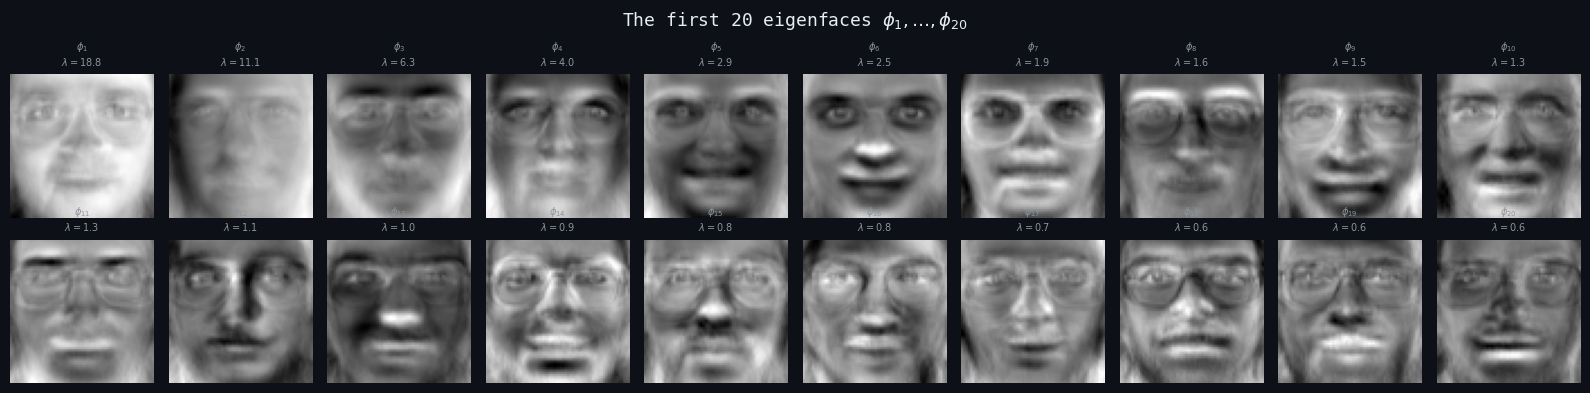

In [8]:
n_show = 20
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle("The first 20 eigenfaces $\\phi_1, \\ldots, \\phi_{20}$",
             color="#e6edf3", fontsize=13)

for idx, ax in enumerate(axes.flat):
    ef = eigenfaces[idx].reshape(n_pixels, n_pixels)
    # Normalize for display
    ef_norm = (ef - ef.min()) / (ef.max() - ef.min())
    ax.imshow(ef_norm, cmap="gray")
    ax.set_title(f"$\\phi_{{{idx+1}}}$\n$\\lambda={eigenvalues[idx]:.1f}$",
                 color="#8b949e", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../assets/eigenfaces_grid.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

## 7. Verifying the Spectral Decomposition Numerically

The Spectral Theorem says $\sum_{i=1}^n P_i = I$.

Numerically: $\sum_{i=1}^k P_i \to I$ as $k \to n$.

We verify: $\left\|\sum_{i=1}^k \phi_i \phi_i^\top - I\right\|_F \to 0$.

(We use a $50$-dimensional subspace for speed.)

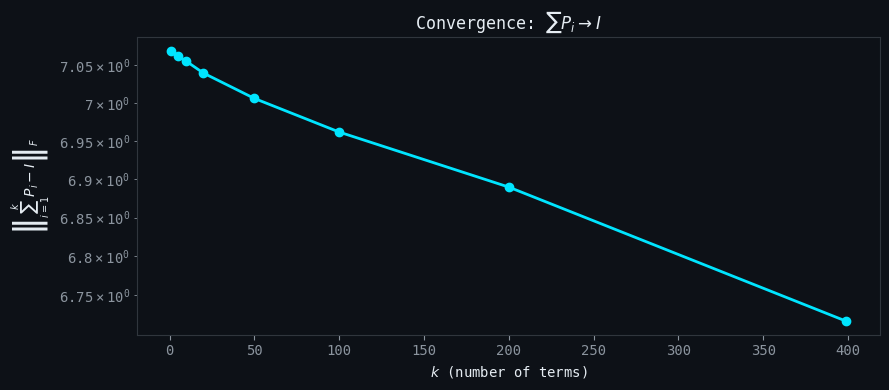

In [9]:
d_small = 50   # work in a 50-dim subspace for speed
V50 = eigenfaces[:, :d_small]   # (400, 50) — first 50 coordinates

ks = [1, 5, 10, 20, 50, 100, 200, 399]
errors = []

for k in ks:
    # Σᵢ₌₁ᵏ φᵢφᵢᵀ in the 50-dim projection
    sum_proj = V50[:k].T @ V50[:k]   # (50, 50)
    error = np.linalg.norm(sum_proj - np.eye(d_small), "fro")
    errors.append(error)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, errors, "o-", color=CYAN, lw=2, ms=6)
ax.set_xlabel("$k$ (number of terms)")
ax.set_ylabel(r"$\left\|\sum_{i=1}^k P_i - I\right\|_F$")
ax.set_title(r"Convergence: $\sum P_i \to I$", color="#e6edf3")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 8. Face Reconstruction via the Spectral Theorem

For any face $f \in \mathbb{R}^{4096}$, the Spectral Theorem gives:

$$f - \bar{f} = \sum_{i=1}^{400} \langle f - \bar{f},\, \phi_i \rangle\, \phi_i
             = \sum_{i=1}^{400} P_i(f - \bar{f})$$

Truncating to $k$ terms gives the **best rank-$k$ approximation**:

$$\hat{f}_k = \bar{f} + \sum_{i=1}^{k} \langle f - \bar{f},\, \phi_i \rangle\, \phi_i$$

The reconstruction error is:
$$\|f - \hat{f}_k\|^2 = \sum_{i=k+1}^{400} \langle f-\bar{f},\,\phi_i\rangle^2
                      = \sum_{i=k+1}^{400} \lambda_i \cdot \left(\frac{\langle f-\bar{f},\phi_i\rangle^2}{\lambda_i}\right)$$

which decreases monotonically as $k$ increases (we project onto more eigenspaces).

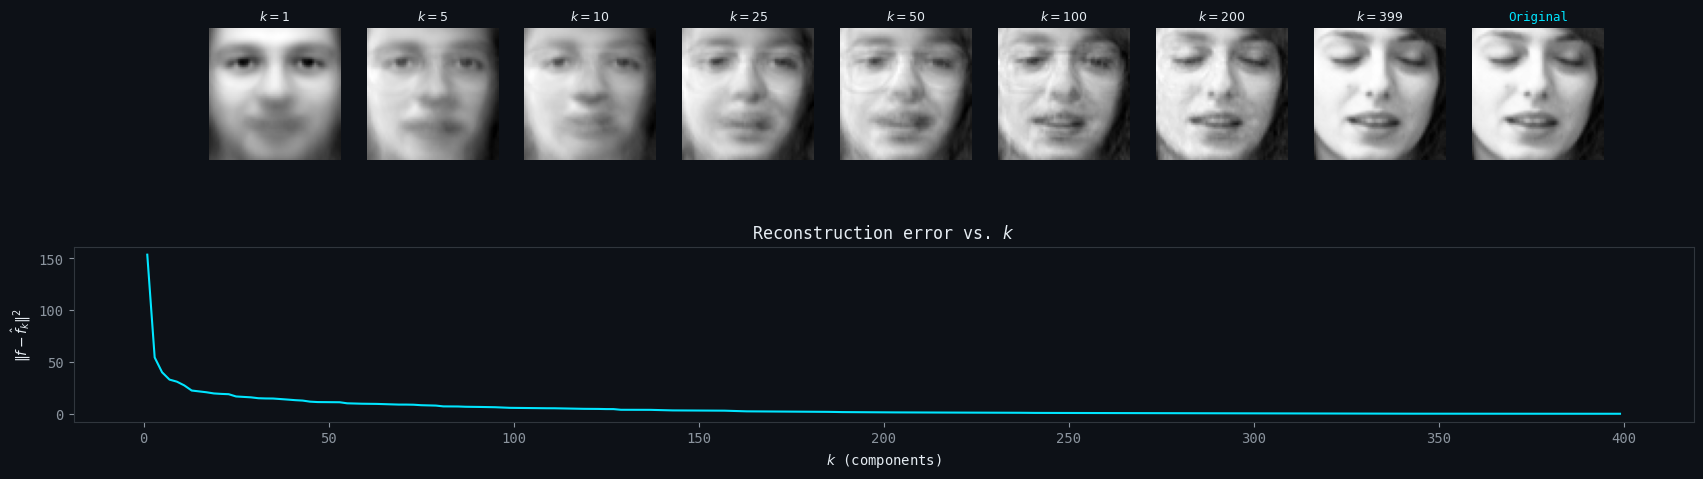

In [10]:
face_idx = 42  # Pick a face
face = X[face_idx]
face_centered = face - mean_face

ks_show = [1, 5, 10, 25, 50, 100, 200, 399]

fig, axes = plt.subplots(2, len(ks_show) + 1, figsize=(18, 5))

# Top row: reconstructed faces
for col, k in enumerate(ks_show):
    coeffs = eigenfaces[:k] @ face_centered         # (k,) projections
    recon = mean_face + eigenfaces[:k].T @ coeffs   # (4096,)
    recon = np.clip(recon, 0, 1)
    axes[0, col].imshow(recon.reshape(n_pixels, n_pixels), cmap="gray")
    axes[0, col].set_title(f"$k={k}$", color="#e6edf3", fontsize=9)
    axes[0, col].axis("off")

# Original
axes[0, -1].imshow(face.reshape(n_pixels, n_pixels), cmap="gray")
axes[0, -1].set_title("Original", color=CYAN, fontsize=9)
axes[0, -1].axis("off")

# Bottom row: reconstruction errors
all_ks = range(1, 400, 2)
recon_errors = []
for k in all_ks:
    coeffs = eigenfaces[:k] @ face_centered
    recon = mean_face + eigenfaces[:k].T @ coeffs
    recon_errors.append(np.sum((face - np.clip(recon, 0, 1))**2))

for ax in axes[1]:
    ax.set_visible(False)

ax_err_main = fig.add_axes([0.05, 0.05, 0.9, 0.35])
ax_err_main.plot(list(all_ks), recon_errors, color=CYAN, lw=1.5)
ax_err_main.set_xlabel("$k$ (components)")
ax_err_main.set_ylabel(r"$\|f - \hat{f}_k\|^2$")
ax_err_main.set_title("Reconstruction error vs. $k$", color="#e6edf3")

plt.savefig("../assets/reconstruction_panel.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()

## 9. The Compression Perspective

**Original representation:** $f \in \mathbb{R}^{4096}$: store 4096 numbers.

**Compressed representation with $k$ components:**
- Store $k$ coordinates $\alpha_i = \langle f - \bar{f},\,\phi_i\rangle$
- The eigenfaces $\phi_1,\ldots,\phi_k$ are **shared** across all faces (computed once)
- Compression ratio: $4096 : k$

This is not an approximation of some arbitrary signal but it is the **optimal** rank-$k$
approximation of $f$ in the $L^2$ sense (Eckart-Young theorem).

The eigenvalues $\lambda_i$ tell you exactly how much error the $i$-th component removes.

In [11]:
print(f"{'k':>6}  {'var. explained':>16}  {'compression ratio':>18}  {'storage (numbers)':>18}")
print("-" * 65)
cumvar = np.cumsum(eigenvalues) / eigenvalues.sum()
for k in [1, 5, 10, 25, 50, 100, 200, 399]:
    ratio = n_features / k
    pct = cumvar[k-1] * 100
    print(f"{k:>6}  {pct:>15.1f}%  {ratio:>17.0f}:1  {k:>18}")
print("-" * 65)
print(f"{'Full':>6}  {'100.0':>15}%  {'1':>17}:1  {n_features:>18}")

     k    var. explained   compression ratio   storage (numbers)
-----------------------------------------------------------------
     1             23.8%               4096:1                   1
     5             54.4%                819:1                   5
    10             65.6%                410:1                  10
    25             79.3%                164:1                  25
    50             87.4%                 82:1                  50
   100             93.5%                 41:1                 100
   200             97.9%                 20:1                 200
   399            100.0%                 10:1                 399
-----------------------------------------------------------------
  Full            100.0%                  1:1                4096


## 10. Interactive Reconstruction

Use the sliders to select a face and number of components.
You are watching the Spectral Theorem's projection sum converge in real time.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

def show_reconstruction(face_idx=0, k=10):
    face = X[face_idx]
    face_centered = face - mean_face
    coeffs = eigenfaces[:k] @ face_centered
    recon = np.clip(mean_face + eigenfaces[:k].T @ coeffs, 0, 1)
    err = np.sum((face - recon)**2)
    pct = cumvar[k-1]*100

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
    axes[0].imshow(face.reshape(n_pixels, n_pixels), cmap="gray")
    axes[0].set_title("Original", color="#e6edf3")
    axes[0].axis("off")
    axes[1].imshow(recon.reshape(n_pixels, n_pixels), cmap="gray")
    axes[1].set_title(f"Reconstruction k={k}\n({pct:.1f}% variance)",
                      color=CYAN)
    axes[1].axis("off")
    diff = np.abs(face - recon).reshape(n_pixels, n_pixels)
    axes[2].imshow(diff, cmap="hot")
    axes[2].set_title(f"Error map\n\u2016f\u2212f\u0302\u2016\u00b2={err:.3f}", color="#ff6b6b")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

widgets.interact(
    show_reconstruction,
    face_idx=widgets.IntSlider(min=0, max=399, step=1, value=42,
                               description="Face:"),
    k=widgets.IntSlider(min=1, max=399, step=1, value=10,
                        description="k:"),
)

interactive(children=(IntSlider(value=42, description='Face:', max=399), IntSlider(value=10, description='k:',…

<function __main__.show_reconstruction(face_idx=0, k=10)>

## 11. Summary: The Spectral Theorem, Unpacked

| Spectral Theorem | This demo |
|---|---|
| Symmetric operator $T: V \to V$ | Covariance matrix $C = \frac{1}{n-1}\tilde{X}^\top\tilde{X}$ |
| Eigenvalue $\lambda_i$ | Variance captured by direction $\phi_i$ |
| Eigenvector $\phi_i$ | Eigenface — a basis direction in face space |
| Projection $P_i = \phi_i\phi_i^\top$ | Projection onto the $i$-th face direction |
| $T = \sum \lambda_i P_i$ | $C = \sum \lambda_i \phi_i\phi_i^\top$ |
| $\sum P_i = I$ | Any face = mean + sum of eigenface projections |
| Truncated sum $\sum_{i=1}^k$ | Compressed face with $k$ numbers |

The Spectral Theorem is not just a classification result, it tells you **how to build** 
a basis adapted to your data, and **how much** each basis direction matters.

This is the foundation of PCA, face recognition (Turk & Pentland, 1991), 
JPEG compression, and a large fraction of modern signal processing.